# Vorgehen

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation




# 1. Business Understanding

Grundlagen des Datensatzes:
- Synthetischer Datensatz
- 50.000 Essens-Bestellungen
- 6 indische Städte, Beträge in INR
- Merkmale
    - Bestellkontext: Uhrzeit, Wochenende/Werktag, Regen
    - Bestellung: Küche, Mahlzeit, Restauranttyp, Bestellwert, Rabatt, Liefergebühr
    - Verhalten: Bewertung, Zeit Wiederholungsbestellung
    - Situation: Stimmung, Hunger, Begleichtung
    - Alter

Background:
- Bisher werden Rabatte vermutlich an jeden gegeben. Im Datensatz bekommt ungefähr jede zweite Bestellung einen Rabatt.

Anwendungsfall:
- Vorhersage von Wiederholungsbestellungen für gezielte Rabattvergabe (Auf aktuell 50.000 Bestellungen 4.000 Nutzer)
    - Zielvariable: is_repeat_order
    - Nach jeder Bestellung schätzt das Modell, wie wahrscheinlich der Kunde wieder bestellt, je nachdem wird ein Rabatt vergeben
        - Hohe Wahrscheinlichkeit -> kein Rabatt
        - Geringe Wahrscheinlichkeit -> Rabatt


# 2. Data Understanding

Datensatz:
- https://www.kaggle.com/datasets/rhythmghai/food-ordering-behavior-india-50k-orders?resource=download
- Synthetische Daten
- Autor: Rhythm_Ghai

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("food_ordering_behavior_dataset.csv")
df.head()

,order_id,user_id,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value,discount_applied,delivery_fee,time_taken_to_order,rating_given,is_repeat_order,mood,hunger_level,company,rainy_weather
0,1,2698,35,Pune,Evening,Weekend,Chinese,Dinner,Premium,971,Yes,90,13,1,Yes,Celebrating,High,Partner,No
1,2,3237,44,Mumbai,Night,Weekend,South Indian,Dinner,Budget,442,No,26,13,2,No,Lazy,Low,Family,No
2,3,3626,31,Delhi,Morning,Weekend,Biryani,Breakfast,Mid-range,739,Yes,85,10,2,Yes,Happy,Medium,Friends,No
3,4,3176,23,Delhi,Evening,Weekend,Biryani,Snacks,Mid-range,466,No,44,12,2,No,Happy,Medium,Alone,No
4,5,4824,26,Chandigarh,Morning,Weekday,Chinese,Lunch,Premium,927,Yes,58,13,2,No,Happy,Medium,Partner,Yes


In [4]:
# Anzahl Spalten, Zeilen
print(df.shape)

# Anzahl einzigsartiger Nutzer
print(df["user_id"].nunique())

# Spalten
df.info()

(50000, 19)
4000
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   order_id             50000 non-null  int64
 1   user_id              50000 non-null  int64
 2   age                  50000 non-null  int64
 3   city                 50000 non-null  str  
 4   order_time           50000 non-null  str  
 5   day_type             50000 non-null  str  
 6   cuisine              50000 non-null  str  
 7   meal_type            50000 non-null  str  
 8   restaurant_type      50000 non-null  str  
 9   order_value          50000 non-null  int64
 10  discount_applied     50000 non-null  str  
 11  delivery_fee         50000 non-null  int64
 12  time_taken_to_order  50000 non-null  int64
 13  rating_given         50000 non-null  int64
 14  is_repeat_order      50000 non-null  str  
 15  mood                 50000 non-null  str  
 16  hunger_level    

In [5]:
num_cols = ["age", "order_value", "delivery_fee", "time_taken_to_order", "rating_given"]
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

In [6]:
# Mittelwert, Standartabweichung, Min, Max für numerische Spalten

df[num_cols].describe().T

# Alle Ausprägung der kategorialen Spalten
for c in cat_cols:
    print(c, df[c].unique())

city <StringArray>
['Pune', 'Mumbai', 'Delhi', 'Chandigarh', 'Bangalore', 'Hyderabad']
Length: 6, dtype: str
order_time <StringArray>
['Evening', 'Night', 'Morning', 'Afternoon']
Length: 4, dtype: str
day_type <StringArray>
['Weekend', 'Weekday']
Length: 2, dtype: str
cuisine <StringArray>
['Chinese', 'South Indian', 'Biryani', 'Fast Food', 'North Indian',
 'Desserts']
Length: 6, dtype: str
meal_type <StringArray>
['Dinner', 'Breakfast', 'Snacks', 'Lunch']
Length: 4, dtype: str
restaurant_type <StringArray>
['Premium', 'Budget', 'Mid-range']
Length: 3, dtype: str
discount_applied <StringArray>
['Yes', 'No']
Length: 2, dtype: str
is_repeat_order <StringArray>
['Yes', 'No']
Length: 2, dtype: str
mood <StringArray>
['Celebrating', 'Lazy', 'Happy', 'Stressed']
Length: 4, dtype: str
hunger_level <StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str
company <StringArray>
['Partner', 'Family', 'Friends', 'Alone']
Length: 4, dtype: str
rainy_weather <StringArray>
['No', 'Yes']
Length: 

is_repeat_order
No     0.50028
Yes    0.49972
Name: proportion, dtype: float64


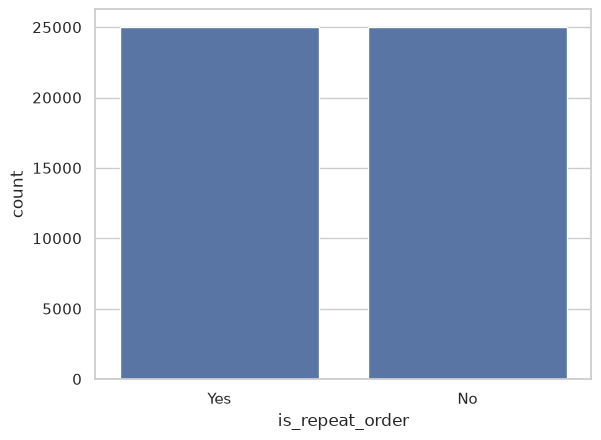

In [7]:
# Zielvariabel anschauen

print(df["is_repeat_order"].value_counts(normalize=True))

# Grafisch darstellen

sns.countplot(data=df, x="is_repeat_order")
plt.show()

# 3. Data Preperation

Da es sich um synthetisch generierte und bereits qualitätsgesicherte Daten handelt, sind fehlende Werte und Duplikate erwartungsgemäß nicht vorhanden. Die Prüfung bestätigt dies. Eine weiterführende Untersuchung der Datenqualität ist an dieser Stelle daher nicht notwendig.

In [8]:
print("Fehlende Werte pro Spalte:")
print(df.isna().sum())
print("Duplizierte Zeilen:", df.duplicated().sum())
print("Duplizierte order_id:", df["order_id"].duplicated().sum())

Fehlende Werte pro Spalte:
order_id               0
user_id                0
age                    0
city                   0
order_time             0
day_type               0
cuisine                0
meal_type              0
restaurant_type        0
order_value            0
discount_applied       0
delivery_fee           0
time_taken_to_order    0
rating_given           0
is_repeat_order        0
mood                   0
hunger_level           0
company                0
rainy_weather          0
dtype: int64
Duplizierte Zeilen: 0
Duplizierte order_id: 0


In [10]:
# Select Data
data = df.copy()

# Order-Id droppen, da es irrelevant ist
data = data.drop(columns=["order_id"])

# Construct Data
# Zeile für die gesamten Kosten hinzufügen
data["total_cost"] = data["order_value"] + data["delivery_fee"]

# Anteil der Liefergebühr am Bestellwert -> hohe Gebühr könnte abschrecken
data["fee_share"] = data["delivery_fee"] / data["order_value"]

# # Altersgruppen statt einzelner Zahlen
data["age_group"] = pd.cut(data["age"], bins=[17, 24, 34, 44], labels=["18-24", "25-34", "35-44"])

# Reformatted Data
# Ja/Nein Spalten in 0/1 umwandeln

yesNoColumns = ["discount_applied", "is_repeat_order", "rainy_weather"]

for c in yesNoColumns:
    data[c] = (data[c] == "Yes").astype(int)

# Ebenfalls für day_type möglich, entweder wochenede oder unter der Woche
data["is_weekend"] = (data["day_type"] == "Weekend").astype(int)
data = data.drop(columns=["day_type"])

# hunger_level ist ordinal -> Reihenfolge beibehalten
data["hunger_level"] = data["hunger_level"].map({"Low": 0, "Medium": 1, "High": 2})

# restliche kategoriale Spalten mit One-Hot-Encoding in 0/1-Spalten aufteilen
# drop_first=True vermeidet redundante Spalten (wichtig für Logistische Regression)
data = pd.get_dummies(data, drop_first=True, dtype=int)

# Dataset Description
# X = Merkmale, y = Zielvariable
X = data.drop(columns=["is_repeat_order"])
y = data["is_repeat_order"]
print(X.shape)
print(X.columns.tolist())

(50000, 38)
['user_id', 'age', 'order_value', 'discount_applied', 'delivery_fee', 'time_taken_to_order', 'rating_given', 'hunger_level', 'rainy_weather', 'total_cost', 'fee_share', 'is_weekend', 'city_Chandigarh', 'city_Delhi', 'city_Hyderabad', 'city_Mumbai', 'city_Pune', 'order_time_Evening', 'order_time_Morning', 'order_time_Night', 'cuisine_Chinese', 'cuisine_Desserts', 'cuisine_Fast Food', 'cuisine_North Indian', 'cuisine_South Indian', 'meal_type_Dinner', 'meal_type_Lunch', 'meal_type_Snacks', 'restaurant_type_Mid-range', 'restaurant_type_Premium', 'mood_Happy', 'mood_Lazy', 'mood_Stressed', 'company_Family', 'company_Friends', 'company_Partner', 'age_group_25-34', 'age_group_35-44']


# 4. Modeling

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

# 80 % Training, 20 % Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Bewertungsmaßnahme:
# - Accuracy: Anteil richtiger Vorhersagen
# - Precision: wie viele Stimmen von allen "Yes"-Vorhersagen
# - Recall: wie viele von den echten "Yes" wurden durch das Modell gefunden
# - F1: Mittel aus Precision und Recall

# Hilfsfunktion zur Bewertung der Modelle
def assess(name, model):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    res = {
        "Modell": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    }
    print(res)

# BASELINE Modell zum Vergleichswert

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

assess("Baseline", baseline)

# Logistische Regression

logreg = make_pipleline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))

logreg.fit(X_train, y_train)

assess("Logisitsche Regression", logreg)

NameError: name 'DummyClassifier' is not defined